In [1]:
# ==========================================
# Cell 1: 导入必要的库并读取数据
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. 读取数据
df = pd.read_csv('../data/cs-training.csv')

# 打印数据维度和违约比例
print(f"原始数据维度: {df.shape}")
print("\n目标变量 (SeriousDlqin2yrs) 分布比例:")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

原始数据维度: (150000, 12)

目标变量 (SeriousDlqin2yrs) 分布比例:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [2]:
# ==========================================
# Cell 2: 划分数据集与物理封存
# ==========================================

# 1. 创建工作副本，并分离 X 和 y
# 删掉无意义的 'Unnamed: 0' 列，操作在副本上进行
df_work = df.drop('Unnamed: 0', axis=1) if 'Unnamed: 0' in df.columns else df.copy()

X = df_work.drop('SeriousDlqin2yrs', axis=1)
y = df_work['SeriousDlqin2yrs']

# 2. 分层划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"✅ 数据划分完成！")
print(f"训练集维度: {X_train.shape}")
print(f"测试集维度: {X_test.shape}")

# 3. 【重点】将未做任何处理的原始测试集进行物理封存
X_test.to_csv('../data/X_test_raw.csv', index=False)
y_test.to_csv('../data/y_test_raw.csv', index=False)

print("\n🔒 [安全] 原始测试集已封存为 'X_test_raw.csv' 和 'y_test_raw.csv'！")

✅ 数据划分完成！
训练集维度: (120000, 10)
测试集维度: (30000, 10)

🔒 [安全] 原始测试集已封存为 'X_test_raw.csv' 和 'y_test_raw.csv'！


In [3]:
# ==========================================
# Cell 3: 异常值处理与统计
# ==========================================

# 从训练集计算正常的年龄中位数
age_median = X_train.loc[X_train['age'] > 0, 'age'].median()

def handle_outliers(data_x, train_age_median, dataset_name="Train"):
    # 【重点】创建数据的深拷贝，绝对不影响传入的原始数据
    df_clean = data_x.copy()
    
    print(f"\n--- 正在处理 {dataset_name} 集异常值 ---")
    
    # 统计并处理：Age = 0
    age_0_count = (df_clean['age'] == 0).sum()
    print(f"[*] 发现 [年龄为0] 的异常记录: {age_0_count} 条。已替换为中位数: {train_age_median}")
    df_clean.loc[df_clean['age'] == 0, 'age'] = train_age_median
    
    # 统计并处理：逾期次数 = 96 或 98
    past_due_cols = [
        'NumberOfTime30-59DaysPastDueNotWorse', 
        'NumberOfTime60-89DaysPastDueNotWorse', 
        'NumberOfTimes90DaysLate'
    ]
    for col in past_due_cols:
        abnormal_count = df_clean[col].isin([96, 98]).sum()
        print(f"[*] 字段 [{col}] 中发现 96/98 异常值: {abnormal_count} 条。已替换为 0。")
        df_clean.loc[df_clean[col].isin([96, 98]), col] = 0
        
    return df_clean

# 分别对训练集和测试集执行清理（测试集虽然被封存了，但为了最终评估模型，也要用训练集的规则清理它）
X_train_clean = handle_outliers(X_train, age_median, "训练(Train)")
X_test_clean = handle_outliers(X_test, age_median, "测试(Test)")


--- 正在处理 训练(Train) 集异常值 ---
[*] 发现 [年龄为0] 的异常记录: 1 条。已替换为中位数: 52.0
[*] 字段 [NumberOfTime30-59DaysPastDueNotWorse] 中发现 96/98 异常值: 214 条。已替换为 0。
[*] 字段 [NumberOfTime60-89DaysPastDueNotWorse] 中发现 96/98 异常值: 214 条。已替换为 0。
[*] 字段 [NumberOfTimes90DaysLate] 中发现 96/98 异常值: 214 条。已替换为 0。

--- 正在处理 测试(Test) 集异常值 ---
[*] 发现 [年龄为0] 的异常记录: 0 条。已替换为中位数: 52.0
[*] 字段 [NumberOfTime30-59DaysPastDueNotWorse] 中发现 96/98 异常值: 55 条。已替换为 0。
[*] 字段 [NumberOfTime60-89DaysPastDueNotWorse] 中发现 96/98 异常值: 55 条。已替换为 0。
[*] 字段 [NumberOfTimes90DaysLate] 中发现 96/98 异常值: 55 条。已替换为 0。


In [4]:
# ==========================================
# Cell 4: 缺失值填补、标准化与导出最终数据
# ==========================================

print("\n--- 正在处理训练集缺失值 ---")
missing_income = X_train_clean['MonthlyIncome'].isnull().sum()
missing_deps = X_train_clean['NumberOfDependents'].isnull().sum()
print(f"[*] 月收入 (MonthlyIncome) 缺失: {missing_income} 条")
print(f"[*] 家属数 (NumberOfDependents) 缺失: {missing_deps} 条")
print("[*] 正在使用训练集中位数进行填补...")

# 1. 缺失值填补
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)
# 测试集只能使用 transform
X_test_imputed = pd.DataFrame(imputer.transform(X_test_clean), columns=X_test_clean.columns)

# 2. 数据标准化
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns)

print("✅ 缺失值填补与标准化完成！")

# 3. 【重点】导出处理完毕的干净数据供后续建模直接使用
X_train_scaled.to_csv('../data/X_train_processed.csv', index=False)
y_train.to_csv('../data/y_train_processed.csv', index=False)
X_test_scaled.to_csv('../data/X_test_processed.csv', index=False)
y_test.to_csv('../data/y_test_processed.csv', index=False)

print("\n💾 [大功告成] 所有清洗和标准化后的数据已保存！")
print("接下来你可以直接读取 'X_train_processed.csv' 等文件开始第三阶段的模型训练。")


--- 正在处理训练集缺失值 ---
[*] 月收入 (MonthlyIncome) 缺失: 23675 条
[*] 家属数 (NumberOfDependents) 缺失: 3128 条
[*] 正在使用训练集中位数进行填补...
✅ 缺失值填补与标准化完成！

💾 [大功告成] 所有清洗和标准化后的数据已保存！
接下来你可以直接读取 'X_train_processed.csv' 等文件开始第三阶段的模型训练。


--- 正在进行特征选择 (相关性分析) ---
发现高度相关的特征对：


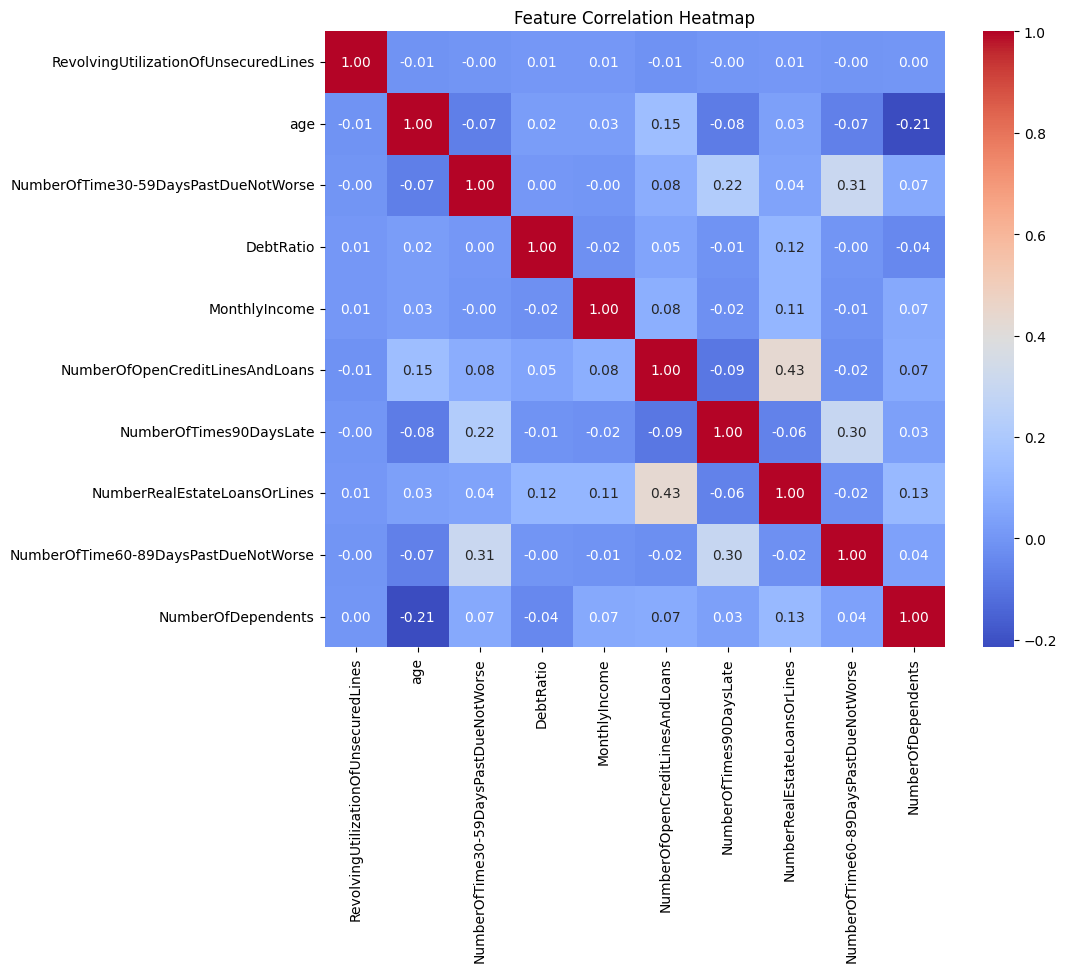

In [6]:
# ==========================================
# Cell 5: 特征选择 (Feature Selection)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 正在进行特征选择 (相关性分析) ---")

# 1. 计算训练集特征的相关性矩阵
corr_matrix = X_train_scaled.corr()

# 2. 找出高度相关的特征对 (绝对值 > 0.75)
high_corr_var = np.where((abs(corr_matrix) > 0.75) & (abs(corr_matrix) != 1.0))
high_corr_pairs = [(corr_matrix.columns[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_var)]

print("发现高度相关的特征对：")
for pair in set(high_corr_pairs):
    print(f"- {pair[0]} 与 {pair[1]}")

# 绘制热力图，这个图可以截图放到你的 PPT 和 Report 里面！
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()